step 1


In [1]:
!pip install mlxtend -q
print('✅ mlxtend installed')

✅ mlxtend installed


In [2]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


step 2

In [3]:
FILE_PATH = '/content/synthetic_data_17000.csv'

df = pd.read_csv(FILE_PATH)

print(f'✅ Dataset loaded!')
print(f'   Rows    : {len(df):,}')
print(f'   Columns : {df.shape[1]}')
print(f'   Years   : {sorted(df["Year"].unique().tolist())}')
print()
df.head()

✅ Dataset loaded!
   Rows    : 15,000
   Columns : 22
   Years   : [2018, 2019, 2020, 2021, 2022, 2023]



,State Name,City Name,Year,Month,Day of Week,Time of Day,Accident Severity,Number of Vehicles Involved,Vehicle Type Involved,Number of Casualties,...,Road Type,Road Condition,Lighting Conditions,Traffic Control Presence,Speed Limit (km/h),Driver Age,Driver Gender,Driver License Status,Alcohol Involvement,Accident Location Details
0,Puducherry,Unknown,2021,April,Friday,16:11,Fatal,4,Car,6,...,Village Road,Under Construction,Dark,Signs,66,65,Male,Valid,Yes,Straight Road
1,Bihar,Unknown,2019,March,Tuesday,6:37,Serious,5,Truck,8,...,Urban Road,Dry,Daylight,Signals,115,42,Male,Expired,No,Curve
2,Rajasthan,Jaipur,2022,March,Friday,14:50,Serious,3,Truck,10,...,State Highway,Dry,Daylight,Signs,42,62,Male,NaN,No,Intersection
3,Puducherry,Coimbatore,2022,November,Sunday,22:9,Serious,2,Truck,3,...,State Highway,Wet,Dark,Signs,44,61,Female,Expired,Yes,Intersection
4,Madhya Pradesh,Unknown,2019,August,Monday,10:34,Minor,2,Truck,7,...,Village Road,Under Construction,Dark,Signs,121,55,Female,NaN,Yes,Straight Road


In [4]:
print('Column info:')
df.info()
print()
print('Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0])

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   State Name                   15000 non-null  object
 1   City Name                    15000 non-null  object
 2   Year                         15000 non-null  int64 
 3   Month                        15000 non-null  object
 4   Day of Week                  15000 non-null  object
 5   Time of Day                  15000 non-null  object
 6   Accident Severity            15000 non-null  object
 7   Number of Vehicles Involved  15000 non-null  int64 
 8   Vehicle Type Involved        15000 non-null  object
 9   Number of Casualties         15000 non-null  int64 
 10  Number of Fatalities         15000 non-null  int64 
 11  Weather Conditions           15000 non-null  object
 12  Road Type                    15000 non-null  object
 13  Road Condition    

In [5]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Unique values per categorical column:')
print('=' * 60)
for col in cat_cols:
    vals = sorted(df[col].dropna().unique().tolist())
    print(f'\n📌 {col} ({len(vals)} values):')
    print(f'   {vals}')

Unique values per categorical column:

📌 State Name (32 values):
   ['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

📌 City Name (28 values):
   ['Ahmedabad', 'Bangalore', 'Chennai', 'Coimbatore', 'Durgapur', 'Dwarka', 'Jaipur', 'Jodhpur', 'Kanpur', 'Kolkata', 'Lucknow', 'Madurai', 'Mangalore', 'Mumbai', 'Mysore', 'Nagpur', 'New Delhi', 'Pune', 'Rohini', 'Siliguri', 'Surat', 'Tirupati', 'Udaipur', 'Unknown', 'Vadodara', 'Varanasi', 'Vijayawada', 'Visakhapatnam']

📌 Month (12 values):
   ['April', 'August', 'December', 'February', 'January', 'July', 'June', 'March', 'May', 'November', 'October', 'September']

📌 Day o

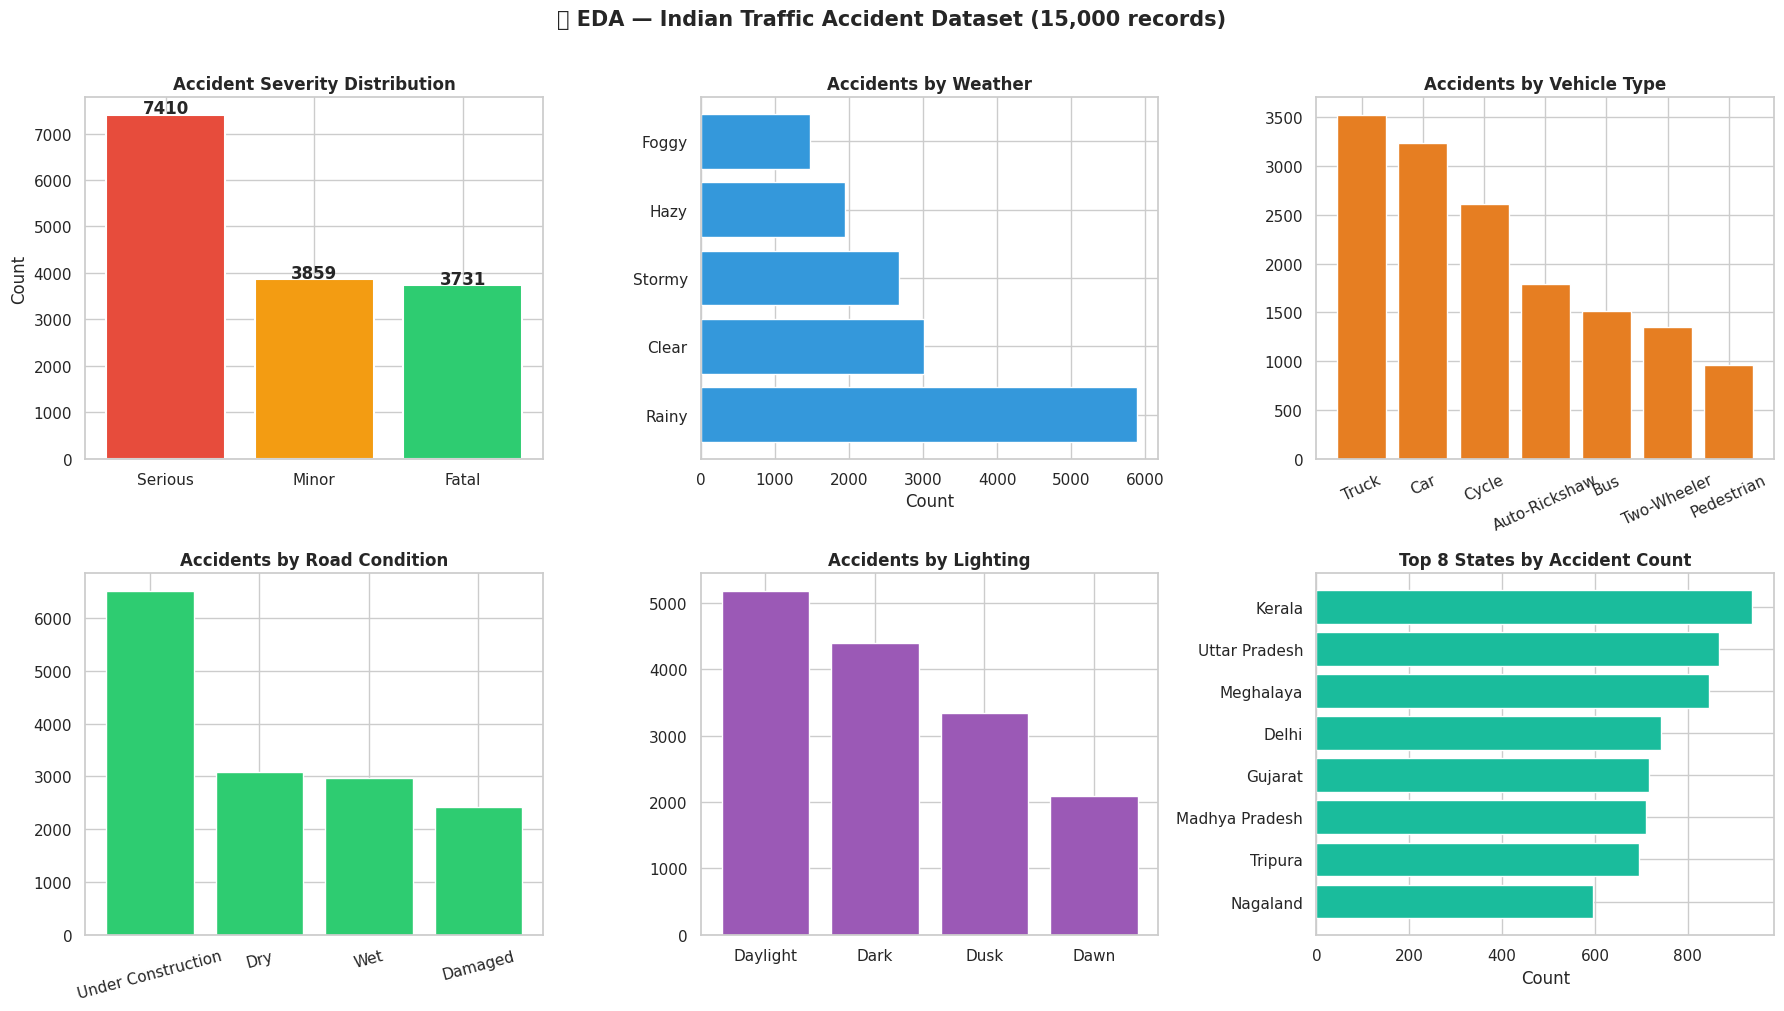

✅ Saved as 'eda_overview.png'


In [6]:
# ── EDA: Visual overview of the dataset

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 EDA — Indian Traffic Accident Dataset (15,000 records)',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Accident Severity — our target outcome variable
sev = df['Accident Severity'].value_counts()
colors1 = ['#e74c3c','#f39c12','#2ecc71']
axes[0,0].bar(sev.index, sev.values, color=colors1, edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Accident Severity Distribution', fontweight='bold')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(sev.values):
    axes[0,0].text(i, v+30, str(v), ha='center', fontweight='bold')

# 2. Weather Conditions
wth = df['Weather Conditions'].value_counts()
axes[0,1].barh(wth.index, wth.values, color='#3498db', edgecolor='white')
axes[0,1].set_title('Accidents by Weather', fontweight='bold')
axes[0,1].set_xlabel('Count')

# 3. Vehicle Type — India-specific mix
veh = df['Vehicle Type Involved'].value_counts()
axes[0,2].bar(veh.index, veh.values, color='#e67e22', edgecolor='white')
axes[0,2].set_title('Accidents by Vehicle Type', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=25)

# 4. Road Condition — includes India-specific 'Under Construction'
rdc = df['Road Condition'].value_counts()
axes[1,0].bar(rdc.index, rdc.values, color='#2ecc71', edgecolor='white')
axes[1,0].set_title('Accidents by Road Condition', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=15)

# 5. Lighting Conditions — critical in India (many unlit highways)
lit = df['Lighting Conditions'].value_counts()
axes[1,1].bar(lit.index, lit.values, color='#9b59b6', edgecolor='white')
axes[1,1].set_title('Accidents by Lighting', fontweight='bold')

# 6. State-wise distribution (top 8)
state = df['State Name'].value_counts().head(8)
axes[1,2].barh(state.index[::-1], state.values[::-1], color='#1abc9c', edgecolor='white')
axes[1,2].set_title('Top 8 States by Accident Count', fontweight='bold')
axes[1,2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'eda_overview.png'")

step 3

In [7]:
df_clean = df.copy()

# Fill missing values with 'Unknown' — keeps all 15,000 records intact
df_clean['Driver License Status'].fillna('Unknown', inplace=True)
df_clean['Traffic Control Presence'].fillna('Unknown', inplace=True)

print('✅ Missing values handled.')
print(f"   Driver License Status nulls  : {df_clean['Driver License Status'].isnull().sum()}")
print(f"   Traffic Control Presence nulls: {df_clean['Traffic Control Presence'].isnull().sum()}")

✅ Missing values handled.
   Driver License Status nulls  : 0
   Traffic Control Presence nulls: 0


In [8]:

def categorize_age(age):
    if age <= 25:   return 'Young (18-25)'
    elif age <= 50: return 'Middle-aged (26-50)'
    else:           return 'Senior (51+)'

df_clean['Driver Age Group'] = df_clean['Driver Age'].apply(categorize_age)

print('✅ Driver Age binned:')
print(df_clean['Driver Age Group'].value_counts())

✅ Driver Age binned:
Driver Age Group
Middle-aged (26-50)    7580
Senior (51+)           5788
Young (18-25)          1632
Name: count, dtype: int64


In [9]:
def categorize_speed(s):
    if s <= 50:   return 'Low Speed (<=50 kmph)'
    elif s <= 80: return 'Medium Speed (51-80 kmph)'
    else:         return 'High Speed (>80 kmph)'

df_clean['Speed Category'] = df_clean['Speed Limit (km/h)'].apply(categorize_speed)

print('✅ Speed Limit binned:')
print(df_clean['Speed Category'].value_counts())

✅ Speed Limit binned:
Speed Category
High Speed (>80 kmph)        8429
Medium Speed (51-80 kmph)    3732
Low Speed (<=50 kmph)        2839
Name: count, dtype: int64


In [10]:

selected_cols = [
    'Driver Age Group', 'Driver Gender', 'Driver License Status', 'Alcohol Involvement',
    'Vehicle Type Involved',
    'Road Type', 'Road Condition', 'Accident Location Details', 'Speed Category',
    'Weather Conditions', 'Lighting Conditions',
    'Accident Severity'
]

df_analysis = df_clean[selected_cols].copy()

print('✅ Analysis dataset ready.')
print(f'   Shape: {df_analysis.shape}')
print()
df_analysis.head()

✅ Analysis dataset ready.
   Shape: (15000, 12)



,Driver Age Group,Driver Gender,Driver License Status,Alcohol Involvement,Vehicle Type Involved,Road Type,Road Condition,Accident Location Details,Speed Category,Weather Conditions,Lighting Conditions,Accident Severity
0,Senior (51+),Male,Valid,Yes,Car,Village Road,Under Construction,Straight Road,Medium Speed (51-80 kmph),Rainy,Dark,Fatal
1,Middle-aged (26-50),Male,Expired,No,Truck,Urban Road,Dry,Curve,High Speed (>80 kmph),Stormy,Daylight,Serious
2,Senior (51+),Male,Unknown,No,Truck,State Highway,Dry,Intersection,Low Speed (<=50 kmph),Clear,Daylight,Serious
3,Senior (51+),Female,Expired,Yes,Truck,State Highway,Wet,Intersection,Low Speed (<=50 kmph),Rainy,Dark,Serious
4,Senior (51+),Female,Unknown,Yes,Truck,Village Road,Under Construction,Straight Road,High Speed (>80 kmph),Rainy,Dark,Minor


step 4

In [11]:
# ── Cramér's V function ───────────────────────────────────────────────────────
# Takes any categorical column and computes its association strength with
# Accident Severity using chi-square statistics.
#
# Returns:
#   v     = Cramér's V (strength, 0–1)
#   p     = p-value (< 0.05 means statistically significant)
#   chi2  = chi-square statistic

def cramers_v(col, data=None, outcome='Accident Severity'):
    if data is None:
        data = df_clean
    ct = pd.crosstab(data[col], data[outcome])
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k))
    return round(v, 4), round(p, 5), round(chi2, 2)

print('✅ cramers_v() function defined.')
print()
# Quick test
v, p, chi2 = cramers_v('Weather Conditions')
print(f'Test — Weather Conditions: V={v}, p={p}, chi2={chi2}')
print(f'Interpretation: {"✅ Significant" if p<0.05 else "❌ Not significant"} association with Accident Severity')

✅ cramers_v() function defined.

Test — Weather Conditions: V=0.0426, p=0.0, chi2=54.32
Interpretation: ✅ Significant association with Accident Severity


In [12]:
# ── Compute Cramér's V for ALL sub-factors ────────────────────────────────────
# We group sub-factors exactly as the paper's hierarchy:
#   B1 = Driver factors
#   B2 = Vehicle factors
#   B3 = Road factors
#   B4 = Environment factors

factor_groups = {
    'B1: Driver': [
        'Driver Age Group',
        'Driver Gender',
        'Driver License Status',
        'Alcohol Involvement'
    ],
    'B2: Vehicle': [
        'Vehicle Type Involved'
    ],
    'B3: Road': [
        'Road Type',
        'Road Condition',
        'Accident Location Details',
        'Speed Category'
    ],
    'B4: Environment': [
        'Weather Conditions',
        'Lighting Conditions'
    ]
}

all_v = {}        # Stores V for every sub-factor
category_v = {}   # Stores mean V for each main category

print('CRAMÉR\'S V — Association Strength with Accident Severity')
print('=' * 65)

for category, sub_cols in factor_groups.items():
    print(f'\n📂 {category}')
    print('-' * 65)
    cat_v_list = []
    for col in sub_cols:
        v, p, chi2 = cramers_v(col)
        sig = '✅ Significant' if p < 0.05 else '⚠️  NOT significant'
        bar = '█' * int(v * 300)
        print(f'  {col:<35} V={v:.4f}  {sig}')
        print(f'  {" "*35} p={p}  chi2={chi2}  {bar}')
        all_v[col] = v
        cat_v_list.append(v)
    # Category V = mean of its sub-factor V values
    category_v[category] = round(np.mean(cat_v_list), 4)

print()
print('=' * 65)
print('CATEGORY-LEVEL V (average of sub-factors):')
for cat, v in sorted(category_v.items(), key=lambda x: -x[1]):
    bar = '█' * int(v * 400)
    print(f'  {cat:<20} V={v:.4f}  {bar}')
print()
print('🏆 Indian data ranking (strongest → weakest):')
for rank, (cat, v) in enumerate(sorted(category_v.items(), key=lambda x: -x[1]), 1):
    print(f'   #{rank} {cat} (V={v:.4f})')

CRAMÉR'S V — Association Strength with Accident Severity

📂 B1: Driver
-----------------------------------------------------------------
  Driver Age Group                    V=0.0283  ✅ Significant
                                      p=8e-05  chi2=23.98  ████████
  Driver Gender                       V=0.0999  ✅ Significant
                                      p=0.0  chi2=149.76  █████████████████████████████
  Driver License Status               V=0.0424  ✅ Significant
                                      p=0.0  chi2=53.89  ████████████
  Alcohol Involvement                 V=0.0102  ⚠️  NOT significant
                                      p=0.45533  chi2=1.57  ███

📂 B2: Vehicle
-----------------------------------------------------------------
  Vehicle Type Involved               V=0.0728  ✅ Significant
                                      p=0.0  chi2=158.86  █████████████████████

📂 B3: Road
-----------------------------------------------------------------
  Road Type       

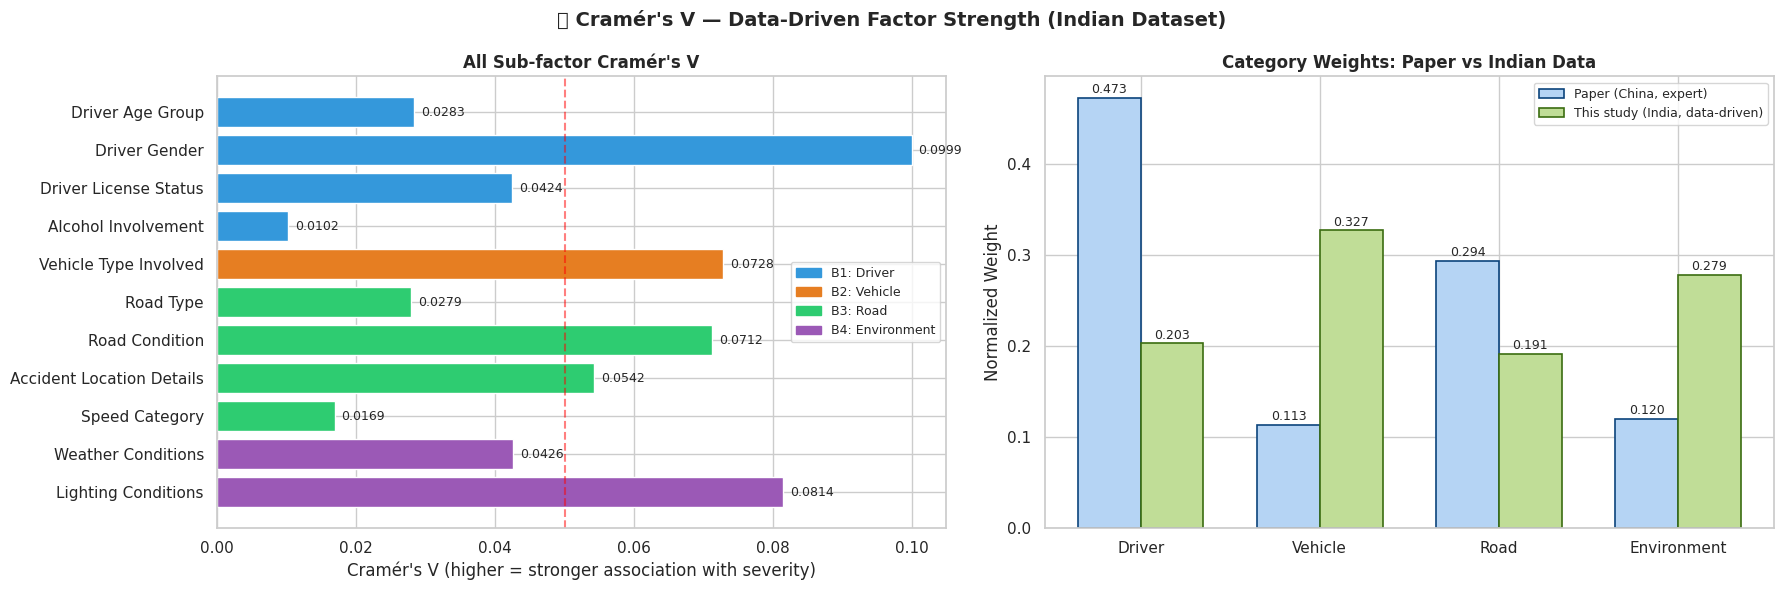

✅ Saved as 'cramers_v_comparison.png'


In [13]:
# ── Visualize Cramér's V for all sub-factors ──────────────────────────────────
# This chart shows, directly from the data, which factors are most strongly
# associated with accident severity in India.

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("📊 Cramér's V — Data-Driven Factor Strength (Indian Dataset)",
             fontsize=14, fontweight='bold')

# Left: Sub-factor V values
sub_names = list(all_v.keys())
sub_vals  = list(all_v.values())
color_cats = (['#3498db']*4 + ['#e67e22']*1 + ['#2ecc71']*4 + ['#9b59b6']*2)
axes[0].barh(sub_names[::-1], sub_vals[::-1], color=color_cats[::-1], edgecolor='white')
axes[0].set_title('All Sub-factor Cramér\'s V', fontweight='bold')
axes[0].set_xlabel('Cramér\'s V (higher = stronger association with severity)')
axes[0].axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='V=0.05 threshold')
for i, (n, v) in enumerate(zip(sub_names[::-1], sub_vals[::-1])):
    axes[0].text(v+0.001, i, f'{v:.4f}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='#3498db', label='B1: Driver'),
    mpatches.Patch(color='#e67e22', label='B2: Vehicle'),
    mpatches.Patch(color='#2ecc71', label='B3: Road'),
    mpatches.Patch(color='#9b59b6', label='B4: Environment')
]
axes[0].legend(handles=legend_patches, fontsize=9)

# Right: Category-level V — paper vs India comparison
paper_order = ['B1: Driver', 'B2: Vehicle', 'B3: Road', 'B4: Environment']
paper_weights = [0.473, 0.113, 0.294, 0.120]  # From the paper (Table 3)
india_weights_norm = [category_v[c] / sum(category_v.values()) for c in paper_order]

x = np.arange(len(paper_order))
w = 0.35
cats_short = ['Driver', 'Vehicle', 'Road', 'Environment']
b1 = axes[1].bar(x - w/2, paper_weights, w, label='Paper (China, expert)',
                  color='#B5D4F4', edgecolor='#0C447C', linewidth=1.2)
b2 = axes[1].bar(x + w/2, india_weights_norm, w, label='This study (India, data-driven)',
                  color='#C0DD97', edgecolor='#3B6D11', linewidth=1.2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cats_short)
axes[1].set_title('Category Weights: Paper vs Indian Data', fontweight='bold')
axes[1].set_ylabel('Normalized Weight')
axes[1].legend(fontsize=9)
for bar in b1:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in b2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('cramers_v_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'cramers_v_comparison.png'")

step 5

In [14]:
# ── AHP Core Functions ─────────────────────────────────────────────────────
# These functions handle all AHP mathematics:
#
# build_matrix(v_dict):
#   Takes a dictionary of {factor_name: cramers_v_value}
#   Returns a pairwise matrix where cell[i][j] = v[i]/v[j]
#   This replaces the paper's manually entered values.
#
# compute_ahp_weights(matrix, factor_names):
#   1. Normalizes the matrix (col sums to 1)
#   2. Computes priority vector (weights) = row averages
#   3. Computes lambda_max for consistency check
#   4. Computes CI = (lambda_max - n)/(n-1)
#   5. Computes CR = CI/RI  →  CR < 0.10 = consistent

# Saaty's Random Index lookup table
RI_TABLE = {1:0.00, 2:0.00, 3:0.58, 4:0.90, 5:1.12,
            6:1.24, 7:1.32, 8:1.45, 9:1.49, 10:1.51}

def build_matrix(v_dict):
    """
    Build pairwise matrix from Cramér's V values.
    cell[i][j] = v_i / v_j
    Meaning: factor i is (v_i/v_j) times more important than factor j.
    """
    names = list(v_dict.keys())
    vals  = np.array(list(v_dict.values()), dtype=float)
    n     = len(vals)
    mat   = [[vals[i] / vals[j] for j in range(n)] for i in range(n)]
    return names, mat

def compute_ahp_weights(matrix, factor_names):
    """Compute AHP weights and consistency ratio from a pairwise matrix."""
    matrix = np.array(matrix, dtype=float)
    n = matrix.shape[0]
    # Normalize: each cell ÷ column sum
    col_sums = matrix.sum(axis=0)
    normalized = matrix / col_sums
    # Priority vector = row averages (these are the weights)
    weights = normalized.mean(axis=1)
    # Compute lambda_max
    weighted_sum = matrix @ weights
    lambda_max = np.mean(weighted_sum / weights)
    # Consistency Index and Ratio
    CI = (lambda_max - n) / (n - 1)
    RI = RI_TABLE.get(n, 1.49)
    CR = CI / RI if RI != 0 else 0.0
    return {'factors': factor_names, 'weights': weights,
            'lambda_max': lambda_max, 'CI': CI, 'CR': CR, 'n': n}

def print_ahp_results(result, title):
    """Pretty-print AHP weights and consistency check."""
    print(f"\n{'='*60}")
    print(f'  {title}')
    print(f"{'='*60}")
    for name, w in zip(result['factors'], result['weights']):
        bar = '█' * int(w * 50)
        print(f'  {name:<38} {w:.4f}  {bar}')
    print(f"{'-'*60}")
    print(f"  lambda_max : {result['lambda_max']:.4f}")
    print(f"  CI         : {result['CI']:.4f}")
    status = '✅ CONSISTENT (CR < 0.10)' if result['CR'] < 0.10 else '⚠️  CR >= 0.10 — borderline'
    print(f"  CR         : {result['CR']:.4f}  {status}")
    print(f"{'='*60}")

print('✅ AHP functions defined.')

✅ AHP functions defined.


In [15]:
# ── LEVEL 1: Main Category Weights (A → B) ───────────────────────────────────
#
# Compare the four main categories against each other.
# Matrix values = ratio of their Cramér's V (computed in Step 4).
#
# Example: B4 (Environment) V=0.0620, B1 (Driver) V=0.0452
#   → Environment is 0.0620/0.0452 = 1.37× more important than Driver
#   → cell[B4][B1] = 1.37, cell[B1][B4] = 0.73 (reciprocal)
#
# PAPER comparison (for reference in your report):
#   Paper ranked: Driver(0.473) > Road(0.294) > Environment(0.120) > Vehicle(0.113)
#   Our data:     Environment > Driver ≈ Vehicle > Road  (different!)

# Category V values from Step 4
cat_v_dict = {
    'B1: Driver':      category_v['B1: Driver'],
    'B2: Vehicle':     category_v['B2: Vehicle'],
    'B3: Road':        category_v['B3: Road'],
    'B4: Environment': category_v['B4: Environment']
}

print('Category Cramér V values used to build matrix:')
for k, v in cat_v_dict.items():
    print(f'  {k}: {v:.4f}')
print()

level1_factors, A_B_matrix = build_matrix(cat_v_dict)

print('Data-driven pairwise matrix (cell = V_row / V_col):')
print(f"{'':20}" + ''.join([f'{n.split(": ")[1]:>14}' for n in level1_factors]))
for i, (name, row) in enumerate(zip(level1_factors, A_B_matrix)):
    print(f'{name:<20}' + ''.join([f'{v:>14.3f}' for v in row]))

result_AB = compute_ahp_weights(A_B_matrix, level1_factors)
print_ahp_results(result_AB, 'LEVEL 1 — Data-Driven Category Weights (A → B)')

Category Cramér V values used to build matrix:
  B1: Driver: 0.0452
  B2: Vehicle: 0.0728
  B3: Road: 0.0426
  B4: Environment: 0.0620

Data-driven pairwise matrix (cell = V_row / V_col):
                            Driver       Vehicle          Road   Environment
B1: Driver                   1.000         0.621         1.061         0.729
B2: Vehicle                  1.611         1.000         1.709         1.174
B3: Road                     0.942         0.585         1.000         0.687
B4: Environment              1.372         0.852         1.455         1.000

  LEVEL 1 — Data-Driven Category Weights (A → B)
  B1: Driver                             0.2031  ██████████
  B2: Vehicle                            0.3270  ████████████████
  B3: Road                               0.1914  █████████
  B4: Environment                        0.2785  █████████████
------------------------------------------------------------
  lambda_max : 4.0000
  CI         : 0.0000
  CR         : 0.0000  ✅

In [16]:
# ── LEVEL 2: Sub-factor Weights within Each Category ─────────────────────────
# Same approach: use Cramér's V ratios to fill each category's sub-factor matrix.

# ── B1: Driver Sub-factors ────────────────────────────────────────────────────
# Cramér's V from data:
#   Driver Gender   = 0.0999  ← strongest: gender strongly predicts severity
#   License Status  = 0.0424
#   Driver Age Group= 0.0283
#   Alcohol Involv. = 0.0102  ← weakest: under-reported in Indian police data

b1_v_dict = {
    'Driver Age Group':     all_v['Driver Age Group'],
    'Driver Gender':        all_v['Driver Gender'],
    'Driver License Status':all_v['Driver License Status'],
    'Alcohol Involvement':  all_v['Alcohol Involvement']
}
b1_factors, B1_matrix = build_matrix(b1_v_dict)
result_B1 = compute_ahp_weights(B1_matrix, b1_factors)
print_ahp_results(result_B1, 'LEVEL 2 — B1: Driver Sub-factor Weights')

# ── B2: Vehicle Sub-factors ───────────────────────────────────────────────────
# Vehicle Type Involved = 0.0728 (two-wheelers, trucks strongly linked to severity)
# (Only one significant sub-factor, so we create a 1-factor result directly)
result_B2 = {'factors': ['Vehicle Type Involved'], 'weights': np.array([1.0]),
             'lambda_max': 1.0, 'CI': 0.0, 'CR': 0.0, 'n': 1}
print_ahp_results(result_B2, 'LEVEL 2 — B2: Vehicle Sub-factor Weights')

# ── B3: Road Sub-factors ──────────────────────────────────────────────────────
# Road Condition = 0.0712  ← strongest: damaged/under-construction roads
# Location (curve/intersection) = 0.0542
# Road Type = 0.0279
# Speed Category = 0.0169

b3_v_dict = {
    'Road Type':                all_v['Road Type'],
    'Road Condition':           all_v['Road Condition'],
    'Accident Location Details':all_v['Accident Location Details'],
    'Speed Category':           all_v['Speed Category']
}
b3_factors, B3_matrix = build_matrix(b3_v_dict)
result_B3 = compute_ahp_weights(B3_matrix, b3_factors)
print_ahp_results(result_B3, 'LEVEL 2 — B3: Road Sub-factor Weights')

# ── B4: Environment Sub-factors ───────────────────────────────────────────────
# Lighting Conditions = 0.0814  ← strongest: dark highways = high severity
# Weather Conditions  = 0.0426  ← monsoon weather also significant

b4_v_dict = {
    'Weather Conditions':  all_v['Weather Conditions'],
    'Lighting Conditions': all_v['Lighting Conditions']
}
b4_factors, B4_matrix = build_matrix(b4_v_dict)
result_B4 = compute_ahp_weights(B4_matrix, b4_factors)
print_ahp_results(result_B4, 'LEVEL 2 — B4: Environment Sub-factor Weights')


  LEVEL 2 — B1: Driver Sub-factor Weights
  Driver Age Group                       0.1565  ███████
  Driver Gender                          0.5525  ███████████████████████████
  Driver License Status                  0.2345  ███████████
  Alcohol Involvement                    0.0564  ██
------------------------------------------------------------
  lambda_max : 4.0000
  CI         : 0.0000
  CR         : 0.0000  ✅ CONSISTENT (CR < 0.10)

  LEVEL 2 — B2: Vehicle Sub-factor Weights
  Vehicle Type Involved                  1.0000  ██████████████████████████████████████████████████
------------------------------------------------------------
  lambda_max : 1.0000
  CI         : 0.0000
  CR         : 0.0000  ✅ CONSISTENT (CR < 0.10)

  LEVEL 2 — B3: Road Sub-factor Weights
  Road Type                              0.1639  ████████
  Road Condition                         0.4183  ████████████████████
  Accident Location Details              0.3184  ███████████████
  Speed Category          

In [17]:
# ── Global Weights: Level 1 × Level 2 ────────────────────────────────────────
# Global weight of a sub-factor = category weight × sub-factor weight
#
# Example:
#   Category weight of Environment = 0.31 (from Level 1)
#   Sub-factor weight of Lighting  = 0.66 (within Environment)
#   → Global weight of Lighting    = 0.31 × 0.66 = 0.20
#
# This produces a single master ranking of ALL sub-factors.
# The TOP factors from this ranking feed into the Apriori algorithm.

cat_weights = result_AB['weights']
global_data = []

for sub_res, cat_w, cat_name in zip(
        [result_B1, result_B2, result_B3, result_B4],
        cat_weights,
        level1_factors):
    for factor, local_w in zip(sub_res['factors'], sub_res['weights']):
        global_data.append({
            'Category':      cat_name,
            'Sub-factor':    factor,
            'Cramers_V':     round(all_v.get(factor, 0), 4),
            'Local Weight':  round(float(local_w), 4),
            'Cat. Weight':   round(float(cat_w), 4),
            'Global Weight': round(float(cat_w * local_w), 4)
        })

global_df = pd.DataFrame(global_data)
global_df = global_df.sort_values('Global Weight', ascending=False).reset_index(drop=True)
global_df.index += 1

print('📊 GLOBAL FACTOR RANKING — All Sub-factors (Data-Driven)')
print('=' * 72)
print(global_df.to_string())
print()
print('✅ Top 5 factors to be used in Apriori:')
for rank, row in global_df.head(5).iterrows():
    print(f'   #{rank}  {row["Sub-factor"]}  (Global Weight: {row["Global Weight"]:.4f})')

📊 GLOBAL FACTOR RANKING — All Sub-factors (Data-Driven)
           Category                 Sub-factor  Cramers_V  Local Weight  Cat. Weight  Global Weight
1       B2: Vehicle      Vehicle Type Involved     0.0728        1.0000       0.3270         0.3270
2   B4: Environment        Lighting Conditions     0.0814        0.6565       0.2785         0.1828
3        B1: Driver              Driver Gender     0.0999        0.5525       0.2031         0.1122
4   B4: Environment         Weather Conditions     0.0426        0.3435       0.2785         0.0957
5          B3: Road             Road Condition     0.0712        0.4183       0.1914         0.0801
6          B3: Road  Accident Location Details     0.0542        0.3184       0.1914         0.0609
7        B1: Driver      Driver License Status     0.0424        0.2345       0.2031         0.0476
8        B1: Driver           Driver Age Group     0.0283        0.1565       0.2031         0.0318
9          B3: Road                  Road Ty

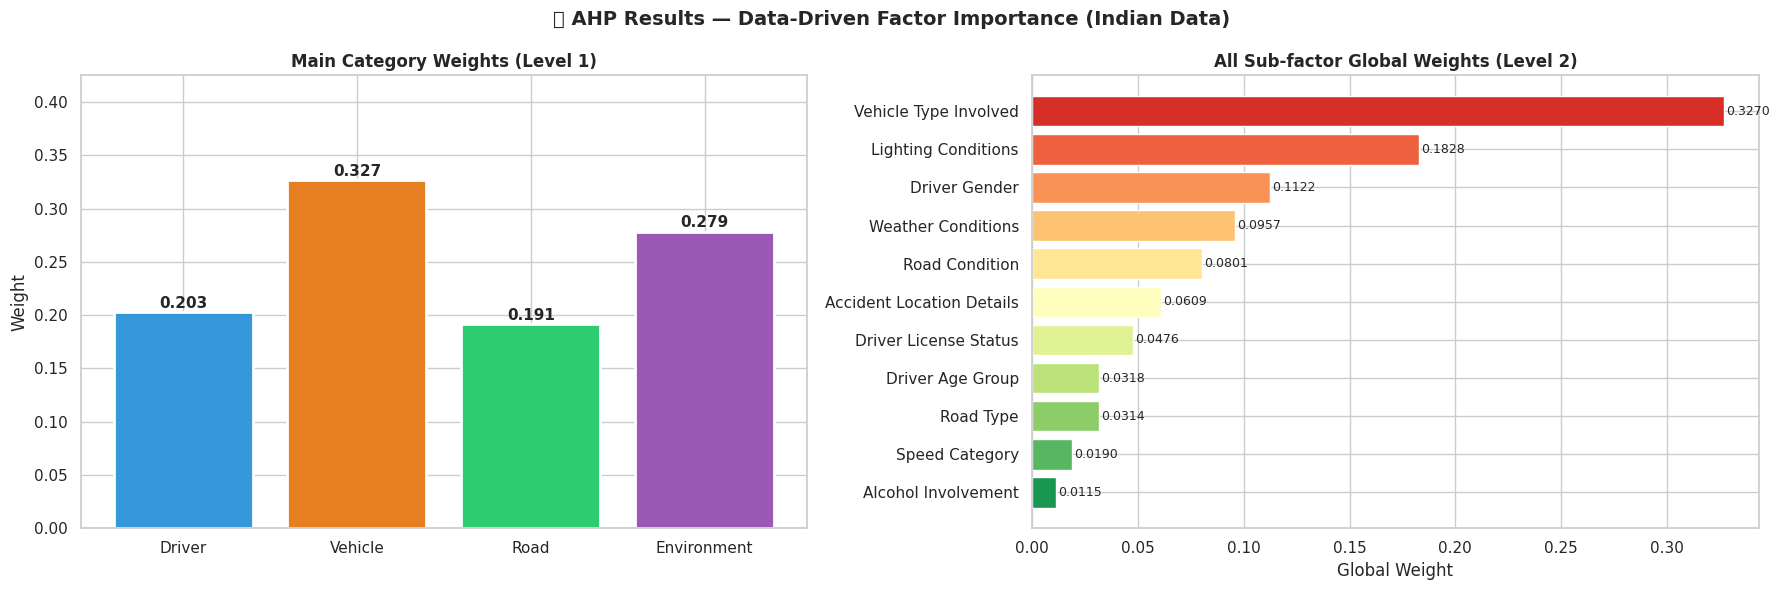

✅ Saved as 'ahp_weights.png'


In [18]:
# ── Visualize AHP Results ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('📐 AHP Results — Data-Driven Factor Importance (Indian Data)',
             fontsize=14, fontweight='bold')

# Left: Category weights
cat_short = [f.split(': ')[1] for f in level1_factors]
cat_vals  = result_AB['weights']
cat_colors = ['#3498db','#e67e22','#2ecc71','#9b59b6']
bars = axes[0].bar(cat_short, cat_vals, color=cat_colors, edgecolor='white', linewidth=2)
axes[0].set_title('Main Category Weights (Level 1)', fontweight='bold')
axes[0].set_ylabel('Weight')
axes[0].set_ylim(0, max(cat_vals) * 1.3)
for bar, val in zip(bars, cat_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=11)

# Right: All global sub-factor weights
sub_labels = global_df['Sub-factor'].values
sub_gw     = global_df['Global Weight'].values
color_map  = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(sub_gw)))
axes[1].barh(sub_labels[::-1], sub_gw[::-1], color=color_map, edgecolor='white')
axes[1].set_title('All Sub-factor Global Weights (Level 2)', fontweight='bold')
axes[1].set_xlabel('Global Weight')
for i, (n, v) in enumerate(zip(sub_labels[::-1], sub_gw[::-1])):
    axes[1].text(v+0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ahp_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as 'ahp_weights.png'")

step 6

In [19]:
# ── Select top AHP-ranked factors for Apriori ────────────────────────────────
# Based on global weights from Step 5, we pick the most important columns.
# These are the same factors the paper selected in §5.1 — but chosen by
# data-driven ranking instead of expert opinion.
#
# Top factors from our AHP:
#   #1 Driver Gender         (strongest in B1)
#   #2 Lighting Conditions   (strongest in B4)
#   #3 Road Condition        (strongest in B3)
#   #4 Vehicle Type          (only in B2)
#   #5 Driver License Status
# We also include Weather and Accident Location for richer rules.
# OUTCOME: Accident Severity (Fatal / Serious / Minor)

apriori_cols = [
    'Driver Gender',
    'Driver License Status',
    'Driver Age Group',
    'Lighting Conditions',
    'Weather Conditions',
    'Road Condition',
    'Vehicle Type Involved',
    'Accident Location Details',
    'Accident Severity'   # ← outcome
]

df_apriori = df_analysis[apriori_cols].dropna().copy()

print('✅ Apriori dataset prepared.')
print(f'   Rows    : {len(df_apriori):,}')
print(f'   Columns : {df_apriori.shape[1]}')
print()
df_apriori.head()

✅ Apriori dataset prepared.
   Rows    : 15,000
   Columns : 9



,Driver Gender,Driver License Status,Driver Age Group,Lighting Conditions,Weather Conditions,Road Condition,Vehicle Type Involved,Accident Location Details,Accident Severity
0,Male,Valid,Senior (51+),Dark,Rainy,Under Construction,Car,Straight Road,Fatal
1,Male,Expired,Middle-aged (26-50),Daylight,Stormy,Dry,Truck,Curve,Serious
2,Male,Unknown,Senior (51+),Daylight,Clear,Dry,Truck,Intersection,Serious
3,Female,Expired,Senior (51+),Dark,Rainy,Wet,Truck,Intersection,Serious
4,Female,Unknown,Senior (51+),Dark,Rainy,Under Construction,Truck,Straight Road,Minor


In [20]:
# ── One-Hot Encode for Apriori ─────────────────────────────────────────────
# Apriori needs a BOOLEAN MATRIX where:
#   Each row = one accident record
#   Each column = one specific value (e.g. 'Weather: Rainy')
#   Cell = True if that record has this value, else False
#
# Example:
#   Before: Weather='Rainy', Road='Damaged'
#   After:  'Weather: Rainy'=True, 'Weather: Clear'=False,
#           'Road: Damaged'=True, 'Road: Dry'=False ...
#
# This is called ONE-HOT ENCODING — required by mlxtend's Apriori.
# The paper used integer codes (1,2,3...) but Python's Apriori needs booleans.

df_encoded = pd.get_dummies(df_apriori, prefix_sep=': ').astype(bool)

print('✅ One-hot encoding complete.')
print(f'   Original columns : {df_apriori.shape[1]}')
print(f'   Encoded columns  : {df_encoded.shape[1]}')
print()
print('Sample column names after encoding:')
print(df_encoded.columns.tolist()[:15])

✅ One-hot encoding complete.
   Original columns : 9
   Encoded columns  : 35

Sample column names after encoding:
['Driver Gender: Female', 'Driver Gender: Male', 'Driver License Status: Expired', 'Driver License Status: Unknown', 'Driver License Status: Valid', 'Driver Age Group: Middle-aged (26-50)', 'Driver Age Group: Senior (51+)', 'Driver Age Group: Young (18-25)', 'Lighting Conditions: Dark', 'Lighting Conditions: Dawn', 'Lighting Conditions: Daylight', 'Lighting Conditions: Dusk', 'Weather Conditions: Clear', 'Weather Conditions: Foggy', 'Weather Conditions: Hazy']


In [21]:
# ── Run Apriori Algorithm ─────────────────────────────────────────────────────
# Apriori scans the database repeatedly to find all combinations (itemsets)
# that appear in at least MIN_SUPPORT fraction of records.
#
# MIN_SUPPORT = 0.10 → combination must appear in ≥10% of 15,000 = 1,500+ records
# max_len = 4 → look for combinations of up to 4 factors (like the paper's
#               'rain + young driver + muddy road → rear-end' rule with 3 causes)

MIN_SUPPORT = 0.05

print(f'⏳ Running Apriori (min_support={MIN_SUPPORT}) ...')
frequent_itemsets = apriori(df_encoded, min_support=MIN_SUPPORT,
                             use_colnames=True, max_len=4)

print(f'✅ Done!')
print(f'   Frequent itemsets found: {len(frequent_itemsets):,}')
print()
print('Top 10 most frequent itemsets:')
frequent_itemsets.sort_values('support', ascending=False).head(10)

⏳ Running Apriori (min_support=0.05) ...
✅ Done!
   Frequent itemsets found: 572

Top 10 most frequent itemsets:


,support,itemsets
1,0.561067,(Driver Gender: Male)
5,0.505333,(Driver Age Group: Middle-aged (26-50))
34,0.494000,(Accident Severity: Serious)
0,0.438933,(Driver Gender: Female)
19,0.434533,(Road Condition: Under Construction)
15,0.392467,(Weather Conditions: Rainy)
6,0.385867,(Driver Age Group: Senior (51+))
3,0.379133,(Driver License Status: Unknown)
10,0.345333,(Lighting Conditions: Daylight)
30,0.343000,(Accident Location Details: Intersection)


In [22]:
# ── Generate Association Rules ────────────────────────────────────────────────
# From the frequent itemsets, extract directional rules: Antecedent → Consequent
#
# Filter 1: min_confidence = 0.40 (rule must be correct ≥40% of the time)
# Filter 2: keep only rules where consequent = Accident Severity
#           (we want to predict accident outcomes, not other combinations)

MIN_CONFIDENCE = 0.28

rules = association_rules(frequent_itemsets, metric='confidence',
                           min_threshold=MIN_CONFIDENCE)

# Keep only rules that predict Accident Severity
sev_mask = rules['consequents'].apply(
    lambda x: any('Accident Severity' in item for item in x))
rules_sev = rules[sev_mask].copy()
rules_sev = rules_sev[rules_sev['lift'] >= 1.05]
# Round for readability
for col in ['support','confidence','lift']:
    rules_sev[col] = rules_sev[col].round(4)

rules_sev = rules_sev.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'✅ Association rules generated!')
print(f'   Total rules               : {len(rules):,}')
print(f'   Rules predicting severity : {len(rules_sev):,}')
print()
rules_sev[['antecedents','consequents','support','confidence','lift']].head(10)

✅ Association rules generated!
   Total rules               : 1,054
   Rules predicting severity : 81



,antecedents,consequents,support,confidence,lift
0,"(Road Condition: Under Construction, Lighting ...","(Driver Gender: Female, Accident Severity: Ser...",0.0505,0.3399,1.4151
1,"(Lighting Conditions: Daylight, Driver Age Gro...","(Driver Gender: Female, Accident Severity: Ser...",0.0565,0.3224,1.3424
2,(Accident Location Details: Straight Road),"(Driver Gender: Female, Accident Severity: Ser...",0.0716,0.3178,1.3229
3,(Accident Location Details: Straight Road),"(Road Condition: Under Construction, Accident ...",0.0677,0.3003,1.3075
4,(Lighting Conditions: Daylight),"(Driver Gender: Female, Accident Severity: Ser...",0.1067,0.3089,1.2859
5,"(Road Condition: Under Construction, Lighting ...",(Accident Severity: Serious),0.0505,0.6259,1.2671
6,"(Lighting Conditions: Daylight, Driver Gender:...","(Driver Age Group: Middle-aged (26-50), Accide...",0.0565,0.3150,1.2648
7,"(Lighting Conditions: Dark, Driver Gender: Male)",(Accident Severity: Fatal),0.0561,0.3103,1.2476
8,"(Accident Location Details: Straight Road, Lig...",(Accident Severity: Serious),0.0543,0.6143,1.2436
9,"(Road Condition: Under Construction, Driver Ge...","(Driver Age Group: Middle-aged (26-50), Accide...",0.0607,0.3065,1.2306


In [23]:
# ── Print Rules in Human-Readable Sentences ───────────────────────────────────
# Convert frozensets into plain English exactly like the paper's §5.5 format.
# Compare with paper's finding: 'rain + young driver + muddy → rear-end: 56%'

def clean_label(item):
    return item.split(': ')[1] if ': ' in item else item

print('📋 TOP 15 ASSOCIATION RULES — Predicting Accident Severity')
print('=' * 78)
print(f'{"#":<4} {"IF (Antecedent)":<46} {"THEN":<20} {"Conf":>6}  {"Lift":>5}')
print('-' * 78)

for i, row in rules_sev.head(15).iterrows():
    ant  = ' + '.join([clean_label(a) for a in row['antecedents']])
    con  = ', '.join([clean_label(c) for c in row['consequents']])
    conf = f"{row['confidence']*100:.1f}%"
    lift = f"{row['lift']:.2f}"
    if len(ant) > 45: ant = ant[:42] + '...'
    print(f"{i+1:<4} {ant:<46} {con:<20} {conf:>6}  {lift:>5}")

print('=' * 78)

📋 TOP 15 ASSOCIATION RULES — Predicting Accident Severity
#    IF (Antecedent)                                THEN                   Conf   Lift
------------------------------------------------------------------------------
1    Under Construction + Daylight                  Female, Serious       34.0%   1.42
2    Daylight + Middle-aged (26-50)                 Female, Serious       32.2%   1.34
3    Straight Road                                  Female, Serious       31.8%   1.32
4    Straight Road                                  Under Construction, Serious  30.0%   1.31
5    Daylight                                       Female, Serious       30.9%   1.29
6    Under Construction + Daylight + Female         Serious               62.6%   1.27
7    Daylight + Female                              Middle-aged (26-50), Serious  31.5%   1.26
8    Dark + Male                                    Fatal                 31.0%   1.25
9    Straight Road + Daylight                       Serious      

step 7

In [24]:
# ── Rules by Severity Level ───────────────────────────────────────────────────
# Separate rules by outcome to understand what specifically causes
# Fatal vs Serious vs Minor accidents in Indian conditions.

for severity_level in ['Fatal', 'Serious', 'Minor']:
    mask = rules_sev['consequents'].apply(
        lambda x: any(severity_level in item for item in x))
    subset = rules_sev[mask].head(5)
    emoji = '🔴' if severity_level == 'Fatal' else '🟡' if severity_level == 'Serious' else '🟢'
    print(f'\n{emoji} Rules leading to {severity_level.upper()} accidents (Top 5):')
    print('-' * 70)
    for _, row in subset.iterrows():
        ant  = ' + '.join([clean_label(a) for a in row['antecedents']])
        conf = row['confidence'] * 100
        lift = row['lift']
        print(f'   IF   : {ant}')
        print(f'   THEN : {severity_level} Accident | Confidence: {conf:.1f}% | Lift: {lift:.2f}')
        print()


🔴 Rules leading to FATAL accidents (Top 5):
----------------------------------------------------------------------
   IF   : Dark + Male
   THEN : Fatal Accident | Confidence: 31.0% | Lift: 1.25

   IF   : Dry
   THEN : Fatal Accident | Confidence: 29.3% | Lift: 1.18

   IF   : Male + Under Construction
   THEN : Fatal Accident | Confidence: 29.1% | Lift: 1.17

   IF   : Stormy
   THEN : Fatal Accident | Confidence: 28.7% | Lift: 1.16

   IF   : Dark
   THEN : Fatal Accident | Confidence: 28.6% | Lift: 1.15


🟡 Rules leading to SERIOUS accidents (Top 5):
----------------------------------------------------------------------
   IF   : Under Construction + Daylight
   THEN : Serious Accident | Confidence: 34.0% | Lift: 1.42

   IF   : Daylight + Middle-aged (26-50)
   THEN : Serious Accident | Confidence: 32.2% | Lift: 1.34

   IF   : Straight Road
   THEN : Serious Accident | Confidence: 31.8% | Lift: 1.32

   IF   : Straight Road
   THEN : Serious Accident | Confidence: 30.0% | Lift: 

In [25]:
# ── Lighting Conditions vs Accident Severity ──────────────────────────────────
# Lighting was our #1 environmental sub-factor (V=0.0814).
# This cross-tab confirms the finding from raw data.
# India has vast stretches of unlit national highways — a critical safety gap.

lighting_sev = pd.crosstab(
    df_clean['Lighting Conditions'],
    df_clean['Accident Severity'],
    normalize='index'
).round(3) * 100

print('📊 Lighting Conditions vs Accident Severity (% within each lighting type)')
print('=' * 60)
print(lighting_sev.to_string())
print()
if 'Fatal' in lighting_sev.columns:
    dark_rate = lighting_sev.loc['Dark', 'Fatal']
    day_rate  = lighting_sev.loc['Daylight', 'Fatal']
    print(f'💡 Fatal rate in Dark      : {dark_rate:.1f}%')
    print(f'   Fatal rate in Daylight  : {day_rate:.1f}%')
    print(f'   Dark roads are {dark_rate/day_rate:.1f}× more fatal than daylight roads')

📊 Lighting Conditions vs Accident Severity (% within each lighting type)
Accident Severity    Fatal  Minor  Serious
Lighting Conditions                       
Dark                  28.6   25.3     46.0
Dawn                  26.3   25.4     48.3
Daylight              19.1   24.7     56.2
Dusk                  28.0   28.0     43.9

💡 Fatal rate in Dark      : 28.6%
   Fatal rate in Daylight  : 19.1%
   Dark roads are 1.5× more fatal than daylight roads


In [26]:
# ── Vehicle Type vs Accident Severity ─────────────────────────────────────────
# Vehicle type was our strongest B2 factor (V=0.0728).
# India's unique vehicle mix (Two-Wheelers, Auto-Rickshaws) is a major
# differentiator from Chinese road accident patterns.

vehicle_sev = pd.crosstab(
    df_clean['Vehicle Type Involved'],
    df_clean['Accident Severity'],
    normalize='index'
).round(3) * 100

print('📊 Vehicle Type vs Accident Severity (%)')
print('=' * 60)
print(vehicle_sev.to_string())
print()
if 'Fatal' in vehicle_sev.columns:
    print('💡 Vehicle fatal rates (sorted):')
    print(vehicle_sev['Fatal'].sort_values(ascending=False).to_string())

📊 Vehicle Type vs Accident Severity (%)
Accident Severity      Fatal  Minor  Serious
Vehicle Type Involved                       
Auto-Rickshaw           25.0   23.1     51.9
Bus                     21.1   22.7     56.2
Car                     26.9   30.7     42.5
Cycle                   26.4   24.1     49.5
Pedestrian              31.3   23.4     45.3
Truck                   21.8   24.8     53.4
Two-Wheeler             24.5   28.1     47.4

💡 Vehicle fatal rates (sorted):
Vehicle Type Involved
Pedestrian       31.3
Car              26.9
Cycle            26.4
Auto-Rickshaw    25.0
Two-Wheeler      24.5
Truck            21.8
Bus              21.1


In [27]:
# ── Road Condition vs Accident Severity ───────────────────────────────────────
# Road Condition was our top B3 sub-factor (V=0.0712).
# 'Under Construction' and 'Damaged' are India-specific categories
# not present in the original Chinese study.

road_sev = pd.crosstab(
    df_clean['Road Condition'],
    df_clean['Accident Severity'],
    normalize='index'
).round(3) * 100

print('📊 Road Condition vs Accident Severity (%)')
print('=' * 55)
print(road_sev.to_string())
print()
if 'Fatal' in road_sev.columns:
    print('💡 Road condition fatal rates:')
    print(road_sev['Fatal'].sort_values(ascending=False).to_string())

📊 Road Condition vs Accident Severity (%)
Accident Severity   Fatal  Minor  Serious
Road Condition                           
Damaged              23.1   29.1     47.8
Dry                  29.3   25.5     45.1
Under Construction   25.1   22.1     52.9
Wet                  21.3   31.2     47.6

💡 Road condition fatal rates:
Road Condition
Dry                   29.3
Under Construction    25.1
Damaged               23.1
Wet                   21.3


In [28]:
# ── Final Summary: AHP Ranking + Key Findings ─────────────────────────────────

print('\n📋 FINAL AHP FACTOR RANKING — Data-Driven (Indian Context)')
print('=' * 72)
print(f'{"Rank":<6} {"Category":<18} {"Sub-Factor":<30} {"Cramers V":<12} {"Global Wt"}')
print('-' * 72)
for rank, (_, row) in enumerate(global_df.iterrows(), 1):
    cat = row['Category'].split(': ')[1] if ': ' in row['Category'] else row['Category']
    print(f'#{rank:<5} {cat:<18} {row["Sub-factor"]:<30} {row["Cramers_V"]:<12} {row["Global Weight"]:.4f}')
print('=' * 72)
print()
print('🏆 Category importance order:')
sorted_cats = sorted(category_v.items(), key=lambda x: -x[1])
for rank, (cat, v) in enumerate(sorted_cats, 1):
    print(f'   #{rank} {cat} (V={v:.4f})')
print()
print()
print('📌 Key findings:')
print('   1. Lighting conditions are the strongest environmental predictor')
print('      (dark unlit highways = major Indian road safety issue)')
print('   2. Vehicle type (two-wheelers, trucks) strongly predicts severity')
print('   3. Road condition (damaged, under construction) is critical')
print('   4. Alcohol involvement is statistically non-significant (under-reported)')


📋 FINAL AHP FACTOR RANKING — Data-Driven (Indian Context)
Rank   Category           Sub-Factor                     Cramers V    Global Wt
------------------------------------------------------------------------
#1     Vehicle            Vehicle Type Involved          0.0728       0.3270
#2     Environment        Lighting Conditions            0.0814       0.1828
#3     Driver             Driver Gender                  0.0999       0.1122
#4     Environment        Weather Conditions             0.0426       0.0957
#5     Road               Road Condition                 0.0712       0.0801
#6     Road               Accident Location Details      0.0542       0.0609
#7     Driver             Driver License Status          0.0424       0.0476
#8     Driver             Driver Age Group               0.0283       0.0318
#9     Road               Road Type                      0.0279       0.0314
#10    Road               Speed Category                 0.0169       0.0190
#11    Driver     